EDA PROJECT ASSIGNMENT – SUPERSTORE SALES ANALYSIS

# Project Title
**Retail Sales Performance & Profitability Analysis**



* This project focuses on analyzing sales and profit data of a retail company
* The goal is to understand how the business is performing and where improvements are needed







* Objective:
The business wants to understand:
1.   Sales performance
→ To understand how much revenue the company is generating
1.   Profitability trends
→ To check whether the company is making profit or loss over time
2.   Customer behavior
→ To understand which customers or segments contribute more to sales
2.   Loss-making areas
→ To identify products, regions, or situations where the company is losing money


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore - Sample - Superstore.csv.csv to Sample - Superstore - Sample - Superstore.csv.csv


In [ ]:
try:
  df=pd.read_csv('Sample - Superstore - Sample - Superstore.csv.csv')
  print('Dataset Loaded Successfully')
except FileNotFoundError:
  print('File not Found')
except Exception as e:
  print('ERROR:',e)

Dataset Loaded Successfully


In [ ]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


# SECTION 1: Data Cleaning & Preparation

**Step 1: Data Understanding**

In [ ]:
df.shape

(9994, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Numerical columns




In [ ]:
num_col=df.select_dtypes(include=["int64","float64"]).columns
num_col

Index(['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit'], dtype='object')

## Categorical columns

In [ ]:
cat_col=df.select_dtypes(include="object").columns
cat_col

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name'],
      dtype='object')

## Date columns

In [ ]:
date_col=df.select_dtypes(include="datetime").columns
date_col

Index([], dtype='object')

**Step 2: NumPy Analysis**

In [ ]:
mean_Sales=df["Sales"].mean()
mean_Sales

np.float64(229.85800083049833)

In [ ]:
median_Profit=df["Profit"].median()
median_Profit

8.6665

In [ ]:
Std_Sales=df["Sales"].std()
Std_Sales

623.2451005086818

In [ ]:
Std_Profit=df["Profit"].std()
Std_Profit

234.26010769095757

In [ ]:
df[num_col].describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
df[num_col].describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [ ]:
Q1=df["Sales"].quantile(0.25)
print("Q1:",Q1)
Q3=df["Sales"].quantile(0.75)
print("Q3:",Q3)
IQR=Q3-Q1
print("IQR:",IQR)
lower=Q1-1.5*IQR
print("Lower:",lower)
upper=Q3+1.5*IQR
print("Upper:",upper)
outlier=df[(df["Sales"]<lower) | (df["Sales"]>upper)]
outlier

Q1: 17.28
Q3: 209.94
IQR: 192.66
Lower: -271.71000000000004
Upper: 498.93


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
10,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
11,12,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.4240,4,0.20,68.3568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9931,9932,CA-2015-104948,11/13/2015,11/17/2015,Standard Class,KH-16510,Keith Herrera,Consumer,United States,San Bernardino,...,92404,West,FUR-BO-10004357,Furniture,Bookcases,O'Sullivan Living Dimensions 3-Shelf Bookcases,683.3320,4,0.15,-40.1960
9942,9943,CA-2014-143371,12/28/2014,1/3/2015,Standard Class,MD-17350,Maribeth Dona,Consumer,United States,Anaheim,...,92804,West,OFF-ST-10001128,Office Supplies,Storage,"Carina Mini System Audio Rack, Model AR050B",998.8200,9,0.00,29.9646
9947,9948,CA-2017-121559,6/1/2017,6/3/2017,Second Class,HW-14935,Helen Wasserman,Corporate,United States,Indianapolis,...,46203,Central,FUR-CH-10003746,Furniture,Chairs,Hon 4070 Series Pagoda Round Back Stacking Chairs,1925.8800,6,0.00,539.2464
9948,9949,CA-2017-121559,6/1/2017,6/3/2017,Second Class,HW-14935,Helen Wasserman,Corporate,United States,Indianapolis,...,46203,Central,OFF-AP-10002945,Office Supplies,Appliances,Honeywell Enviracaire Portable HEPA Air Cleane...,2405.2000,8,0.00,793.7160


In [ ]:
Q1=df["Profit"].quantile(0.25)
print("Q1:",Q1)
Q3=df["Profit"].quantile(0.75)
print("Q3:",Q3)
IQR=Q3-Q1
print("IQR:",IQR)
lower=Q1-1.5*IQR
print("Lower:",lower)
upper=Q3+1.5*IQR
print("Upper:",upper)
outlier=df[(df["Profit"]<lower) | (df["Profit"]>upper)]
outlier

Q1: 1.72875
Q3: 29.364
IQR: 27.63525
Lower: -39.724125
Upper: 70.816875


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
10,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
13,14,CA-2016-161389,12/5/2016,12/10/2016,Standard Class,IM-15070,Irene Maddox,Consumer,United States,Seattle,...,98103,West,OFF-BI-10003656,Office Supplies,Binders,Fellowes PB200 Plastic Comb Binding Machine,407.9760,3,0.20,132.5922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9957,9958,US-2014-143287,11/11/2014,11/17/2014,Standard Class,KN-16705,Kristina Nunn,Home Office,United States,New Rochelle,...,10801,East,OFF-PA-10004039,Office Supplies,Paper,Xerox 1882,223.9200,4,0.00,109.7208
9962,9963,CA-2015-168088,3/19/2015,3/22/2015,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,...,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704
9968,9969,CA-2017-153871,12/11/2017,12/17/2017,Standard Class,RB-19435,Richard Bierner,Consumer,United States,Plainfield,...,7060,East,OFF-BI-10004600,Office Supplies,Binders,Ibico Ibimaster 300 Manual Binding System,735.9800,2,0.00,331.1910
9979,9980,US-2016-103674,12/6/2016,12/10/2016,Standard Class,AP-10720,Anne Pryor,Home Office,United States,Los Angeles,...,90032,West,OFF-BI-10002026,Office Supplies,Binders,Ibico Recycled Linen-Style Covers,437.4720,14,0.20,153.1152


In [ ]:
Q1=df["Quantity"].quantile(0.25)
print("Q1:",Q1)
Q3=df["Quantity"].quantile(0.75)
print("Q3:",Q3)
IQR=Q3-Q1
print("IQR:",IQR)
lower=Q1-1.5*IQR
print("Lower:",lower)
upper=Q3+1.5*IQR
print("Upper:",upper)
outlier=df[(df["Quantity"]<lower) | (df["Quantity"]>upper)]
outlier

Q1: 2.0
Q3: 5.0
IQR: 3.0
Lower: -2.5
Upper: 9.5


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
113,114,CA-2014-115259,8/25/2014,8/27/2014,Second Class,RC-19960,Ryan Crowe,Consumer,United States,Columbus,...,43229,East,OFF-FA-10000621,Office Supplies,Fasteners,"OIC Colored Binder Clips, Assorted Sizes",40.096,14,0.2,14.5348
139,140,CA-2016-145583,10/13/2016,10/19/2016,Standard Class,LC-16885,Lena Creighton,Consumer,United States,Roseville,...,95661,West,FUR-FU-10001706,Furniture,Furnishings,Longer-Life Soft White Bulbs,43.120,14,0.0,20.6976
147,148,CA-2016-114489,12/5/2016,12/9/2016,Standard Class,JE-16165,Justin Ellison,Corporate,United States,Franklin,...,53132,Central,TEC-PH-10000215,Technology,Phones,Plantronics Cordless Phone Headset with In-lin...,384.450,11,0.0,103.8015
251,252,CA-2016-145625,9/11/2016,9/17/2016,Standard Class,KC-16540,Kelly Collister,Consumer,United States,San Diego,...,92037,West,TEC-AC-10003832,Technology,Accessories,Logitech P710e Mobile Speakerphone,3347.370,13,0.0,636.0003
329,330,US-2016-141544,8/30/2016,9/1/2016,First Class,PO-18850,Patrick O'Brill,Consumer,United States,Philadelphia,...,19143,East,OFF-LA-10001074,Office Supplies,Labels,Round Specialty Laser Printer Labels,100.240,10,0.2,33.8310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9882,9883,CA-2014-153927,8/12/2014,8/13/2014,First Class,LL-16840,Lauren Leatherbury,Consumer,United States,Woodstock,...,30188,South,TEC-AC-10000023,Technology,Accessories,"Maxell 74 Minute CD-R Spindle, 50/Pack",272.610,13,0.0,98.1396
9895,9896,CA-2014-115049,9/26/2014,10/1/2014,Standard Class,MM-17920,Michael Moore,Consumer,United States,Chicago,...,60623,Central,TEC-AC-10004859,Technology,Accessories,"Maxell Pro 80 Minute CD-R, 10/Pack",153.824,11,0.2,38.4560
9941,9942,CA-2017-164028,11/24/2017,11/30/2017,Standard Class,JL-15835,John Lee,Consumer,United States,San Francisco,...,94122,West,TEC-AC-10001772,Technology,Accessories,Memorex Mini Travel Drive 16 GB USB 2.0 Flash ...,223.580,14,0.0,87.1962
9979,9980,US-2016-103674,12/6/2016,12/10/2016,Standard Class,AP-10720,Anne Pryor,Home Office,United States,Los Angeles,...,90032,West,OFF-BI-10002026,Office Supplies,Binders,Ibico Recycled Linen-Style Covers,437.472,14,0.2,153.1152


In [ ]:
Q1=df["Discount"].quantile(0.25)
print("Q1:",Q1)
Q3=df["Discount"].quantile(0.75)
print("Q3:",Q3)
IQR=Q3-Q1
print("IQR:",IQR)
lower=Q1-1.5*IQR
print("Lower:",lower)
upper=Q3+1.5*IQR
print("Upper:",upper)
outlier=df[(df["Discount"]<lower) | (df["Discount"]>upper)]
outlier

Q1: 0.0
Q3: 0.2
IQR: 0.2
Lower: -0.30000000000000004
Upper: 0.5


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
14,15,US-2015-118983,11/22/2015,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.810,5,0.8,-123.8580
15,16,US-2015-118983,11/22/2015,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.544,3,0.8,-3.8160
28,29,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,OFF-BI-10000474,Office Supplies,Binders,Avery Recycled Flexi-View Covers for Binding S...,9.618,2,0.7,-7.0532
32,33,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,OFF-BI-10001525,Office Supplies,Binders,"Acco Pressboard Covers with Storage Hooks, 14 ...",6.858,6,0.7,-5.7150
36,37,CA-2016-117590,12/8/2016,12/10/2016,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,75080,Central,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.920,5,0.6,-147.9630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9870,9871,CA-2014-114195,11/1/2014,11/3/2014,First Class,EA-14035,Erin Ashbrook,Corporate,United States,Mason,...,45040,East,OFF-BI-10001658,Office Supplies,Binders,GBC Standard Therm-A-Bind Covers,22.428,3,0.7,-17.9424
9877,9878,US-2017-166324,4/20/2017,4/21/2017,First Class,BE-11455,Brad Eason,Home Office,United States,Cleveland,...,44105,East,OFF-BI-10000174,Office Supplies,Binders,Wilson Jones Clip & Carry Folder Binder Tool f...,8.700,5,0.7,-6.3800
9903,9904,CA-2014-122609,11/12/2014,11/18/2014,Standard Class,DP-13000,Darren Powers,Consumer,United States,Carrollton,...,75007,Central,FUR-FU-10004587,Furniture,Furnishings,"GE General Use Halogen Bulbs, 100 Watts, 1 Bul...",25.128,3,0.6,-6.9102
9920,9921,CA-2016-149272,3/15/2016,3/19/2016,Standard Class,MY-18295,Muhammed Yedwab,Corporate,United States,Bryan,...,77803,Central,OFF-BI-10004233,Office Supplies,Binders,"GBC Pre-Punched Binding Paper, Plastic, White,...",22.386,7,0.8,-35.8176


**Step 3: Data Type Corrections**

In [ ]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

**Step 4: Missing Values**

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df=df.drop("Row ID",axis=1)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [ ]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

**Step 7: Categorical Cleaning**

In [ ]:
print(df["Category"].unique())
print(df["Sub-Category"].unique())
print(df["Region"].unique())

['Furniture' 'Office Supplies' 'Technology']
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']
['South' 'West' 'Central' 'East']


In [ ]:
df["Category"] = df["Category"].str.strip().str.title()
df["Sub-Category"] = df["Sub-Category"].str.strip().str.title()
df["Region"] = df["Region"].str.strip().str.title()

In [ ]:
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [ ]:
print(df["Category"].unique())
print(df["Sub-Category"].unique())
print(df["Region"].unique())

['Furniture' 'Office Supplies' 'Technology']
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']
['South' 'West' 'Central' 'East']


**Step 8: Date Feature Engineering**

In [ ]:
df["Order Month"] = df["Order Date"].dt.month
df["Order Year"] = df["Order Date"].dt.year
df["Order Day"] = df["Order Date"].dt.day

In [ ]:
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Day
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,8
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,8
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,12
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,11
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,...,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,1,2014,21
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2,2017,26
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2,2017,26
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2,2017,26


**Step 9: Delivery Time**

In [ ]:
df["Delivery Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [ ]:
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Day,Delivery Days
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,8,3
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,8,3
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,12,4
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,11,7
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,11,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,...,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,1,2014,21,2
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2,2017,26,5
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2,2017,26,5
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2,2017,26,5


In [ ]:
df = df[df["Delivery Days"] >= 0]
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Day,Delivery Days
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,8,3
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,8,3
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,12,4
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,11,7
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,11,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,...,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,1,2014,21,2
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2,2017,26,5
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2,2017,26,5
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2,2017,26,5


In [ ]:
df[df["Delivery Days"] < 0]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Day,Delivery Days


In [ ]:
df["Profit Margin"] = df["Profit"] / df["Sales"]
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Day,Delivery Days,Profit Margin
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,8,3,0.1600
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,8,3,0.3000
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,12,4,0.4700
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,11,7,-0.4000
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,11,7,0.1125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,...,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,1,2014,21,2,0.1625
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2,2017,26,5,0.1700
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2,2017,26,5,0.0750
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2,2017,26,5,0.4500


In [ ]:
def discount_level(x):
    if x <= 0.2:
        return "Low"
    elif x <= 0.5:
        return "Medium"
    else:
        return "High"

df["Discount Category"] = df["Discount"].apply(discount_level)

In [ ]:
def sales_level(x):
    if x <= 100:
        return "Low"
    elif x <= 500:
        return "Medium"
    elif x <= 1000:
        return "High"
    else:
        return "Premium"

df["Sales Category"] = df["Sales"].apply(sales_level)

In [ ]:
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Quantity,Discount,Profit,Order Month,Order Year,Order Day,Delivery Days,Profit Margin,Discount Category,Sales Category
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,2,0.00,41.9136,11,2016,8,3,0.1600,Low,Medium
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,3,0.00,219.5820,11,2016,8,3,0.3000,Low,High
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,2,0.00,6.8714,6,2016,12,4,0.4700,Low,Low
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,5,0.45,-383.0310,10,2015,11,7,-0.4000,Medium,High
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,2,0.20,2.5164,10,2015,11,7,0.1125,Low,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,...,3,0.20,4.1028,1,2014,21,2,0.1625,Low,Low
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,2,0.00,15.6332,2,2017,26,5,0.1700,Low,Low
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,2,0.20,19.3932,2,2017,26,5,0.0750,Low,Medium
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,4,0.00,13.3200,2,2017,26,5,0.4500,Low,Low


In [ ]:
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Quantity,Discount,Profit,Order Month,Order Year,Order Day,Delivery Days,Profit Margin,Discount Category,Sales Category
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,2,0.00,41.9136,11,2016,8,3,0.1600,Low,Medium
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,3,0.00,219.5820,11,2016,8,3,0.3000,Low,High
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,2,0.00,6.8714,6,2016,12,4,0.4700,Low,Low
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,5,0.45,-383.0310,10,2015,11,7,-0.4000,Medium,High
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,2,0.20,2.5164,10,2015,11,7,0.1125,Low,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,...,3,0.20,4.1028,1,2014,21,2,0.1625,Low,Low
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,2,0.00,15.6332,2,2017,26,5,0.1700,Low,Low
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,2,0.20,19.3932,2,2017,26,5,0.0750,Low,Medium
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,4,0.00,13.3200,2,2017,26,5,0.4500,Low,Low


In [ ]:
print(df) # Displays the entire dataset
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
# Counts duplicate rows
print((df["Delivery Days"] < 0).sum())
# Checks invalid delivery values
print((df["Sales"] < 0).sum())
# Checks if any sales value is negative
print((df["Discount"] < 0).sum())
# Checks invalid discount values

            Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0     CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1     CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2     CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3     US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4     US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
...              ...        ...        ...             ...         ...   
9989  CA-2014-110422 2014-01-21 2014-01-23    Second Class    TB-21400   
9990  CA-2017-121258 2017-02-26 2017-03-03  Standard Class    DB-13060   
9991  CA-2017-121258 2017-02-26 2017-03-03  Standard Class    DB-13060   
9992  CA-2017-121258 2017-02-26 2017-03-03  Standard Class    DB-13060   
9993  CA-2017-119914 2017-05-04 2017-05-09    Second Class    CC-12220   

         Customer Name    Segment        Country             City       State  \
0          Claire Gute   Consu

**SECTION 2: EXPLORATORY DATA ANALYSIS**

**Step 1: Overview**

In [ ]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df.shape[0]

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 2296919.4883000003
Total Profit: 286409.0805
Total Orders: 9993


**Step 2: Univariate Analysis (Matplotlib)**

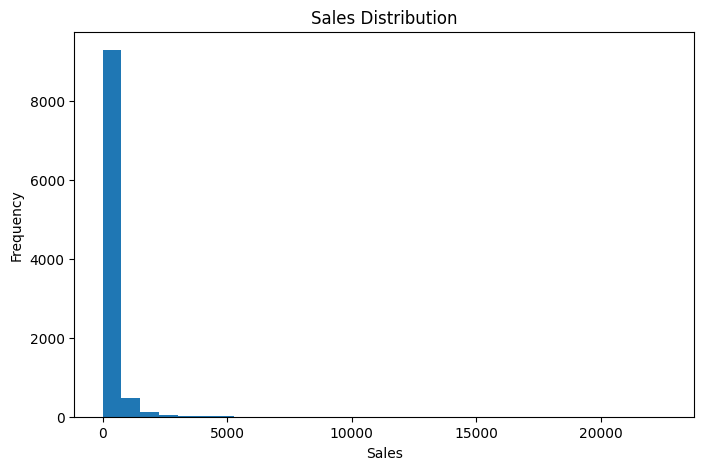

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

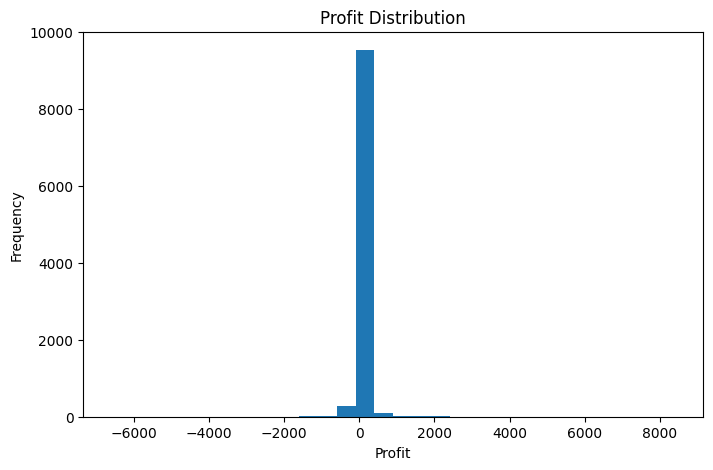

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Profit"], bins=30)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

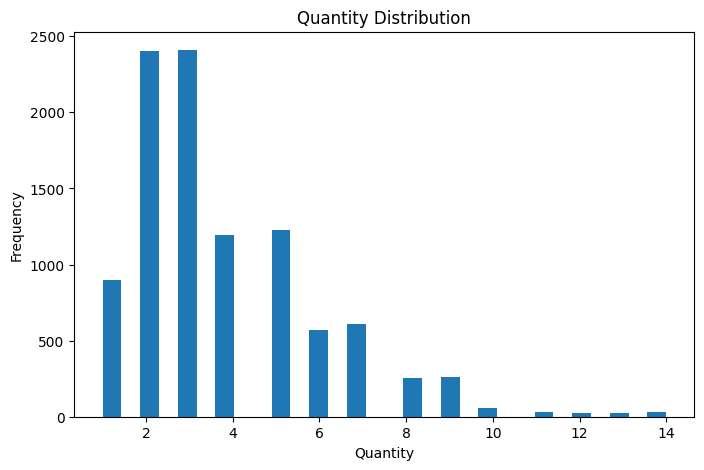

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Quantity"], bins=30)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

**Step 3: Category Analysis (Seaborn)**

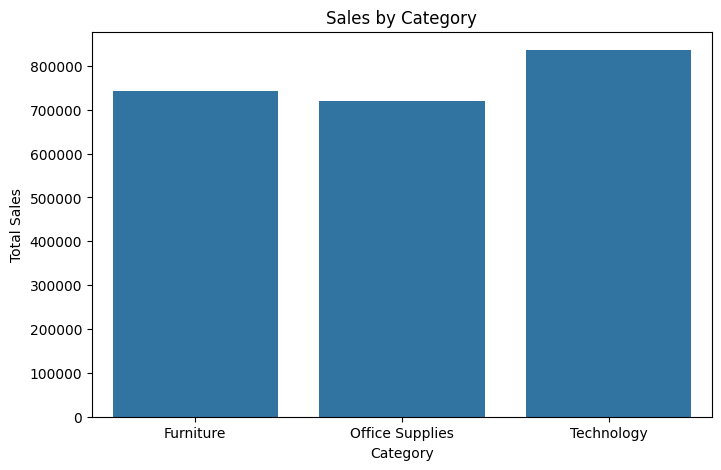

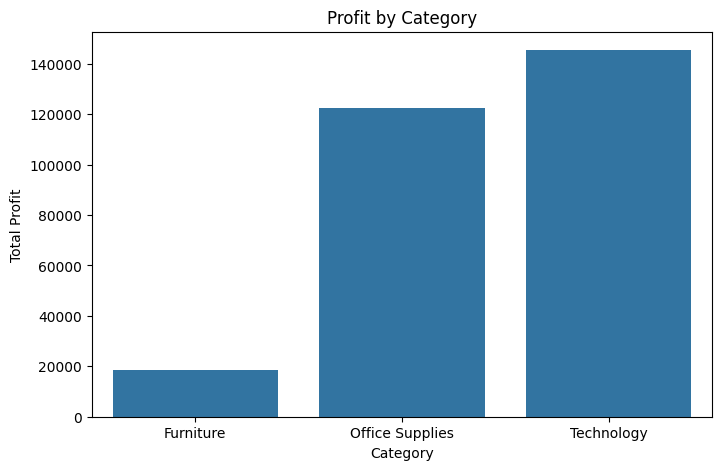

In [ ]:
import seaborn as sns

# Sales by Category
sales_cat = df.groupby("Category")["Sales"].sum().reset_index()
# Groups data by Category and calculates total Sales

plt.figure(figsize=(8,5))
sns.barplot(data=sales_cat, x="Category", y="Sales")
# Creates a bar chart of total sales per category
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

# Profit by Category
profit_cat = df.groupby("Category")["Profit"].sum().reset_index()
# Groups data by Category and calculates total Profit

plt.figure(figsize=(8,5))
sns.barplot(data=profit_cat, x="Category", y="Profit")
# Creates a bar chart of total profit per category
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

**Step 4: Region Analysis**

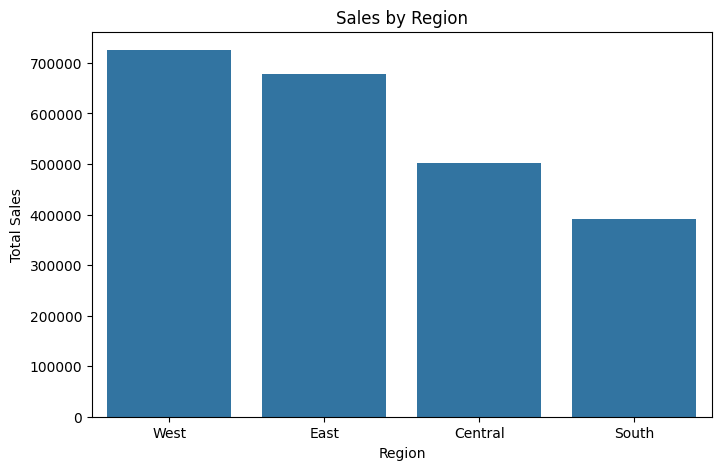

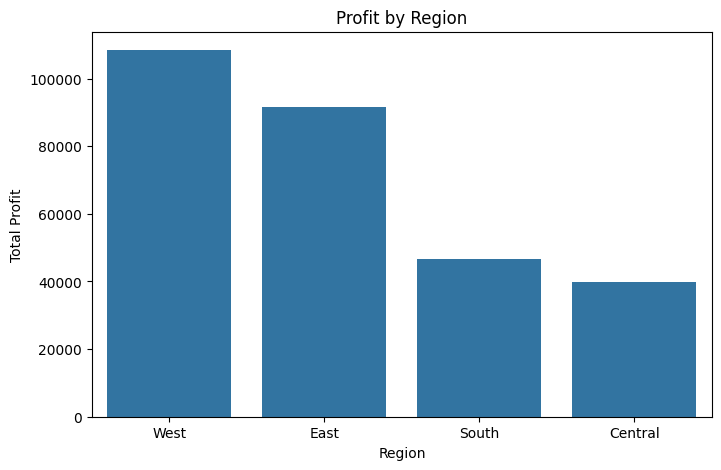

In [ ]:
# Sales by Region
sales_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False).reset_index()
# Groups data by Region
# Calculates total Sales
# Sorts from highest → lowest

plt.figure(figsize=(8,5))
sns.barplot(data=sales_region, x="Region", y="Sales")
# Shows which region generates the most sales
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

profit_region = df.groupby("Region")["Profit"].sum().sort_values(ascending=False).reset_index()
# Groups data by Region
# Calculates total Profit

plt.figure(figsize=(8,5))
sns.barplot(data=profit_region, x="Region", y="Profit")
# Shows which region earns the most profit
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

**Step 5: Discount Impact**

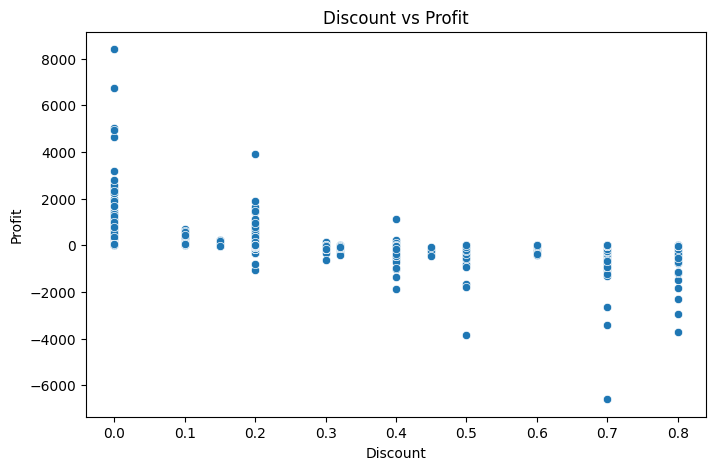

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Discount", y="Profit")
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

**Step 6: Product Analysis**

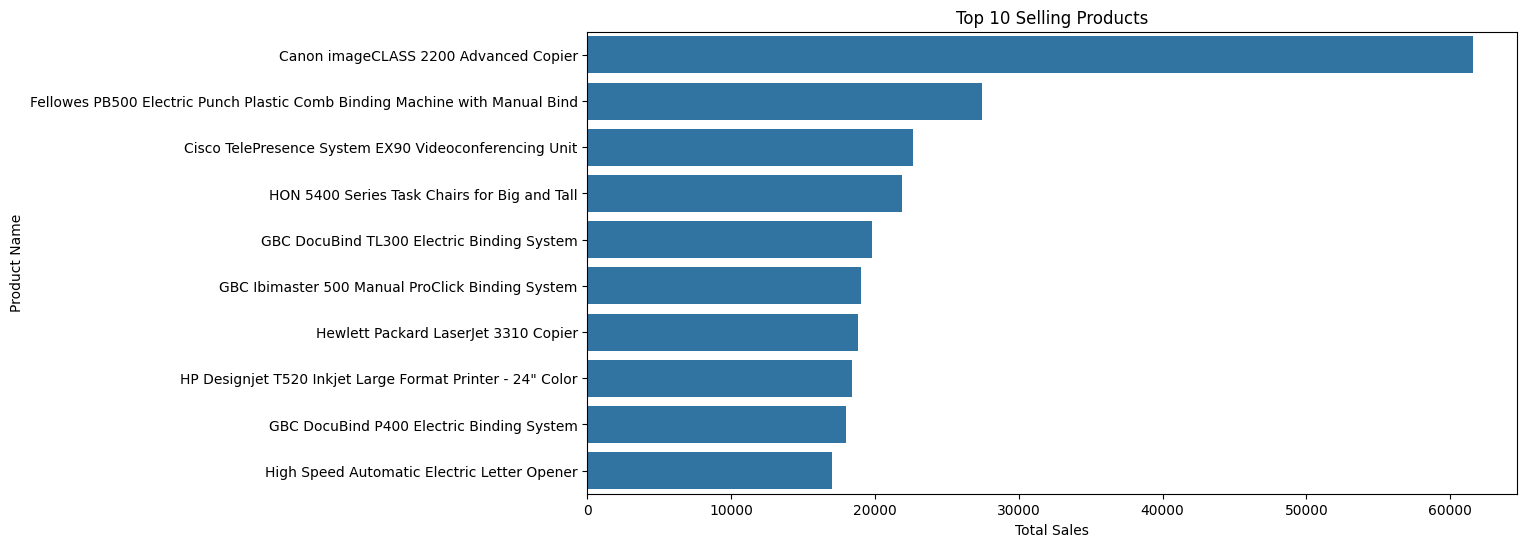

In [ ]:
top_sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10).reset_index()


plt.figure(figsize=(12,6))
sns.barplot(data=top_sales, x="Sales", y="Product Name")
# Creates a horizontal bar chart of top-selling products
plt.title("Top 10 Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

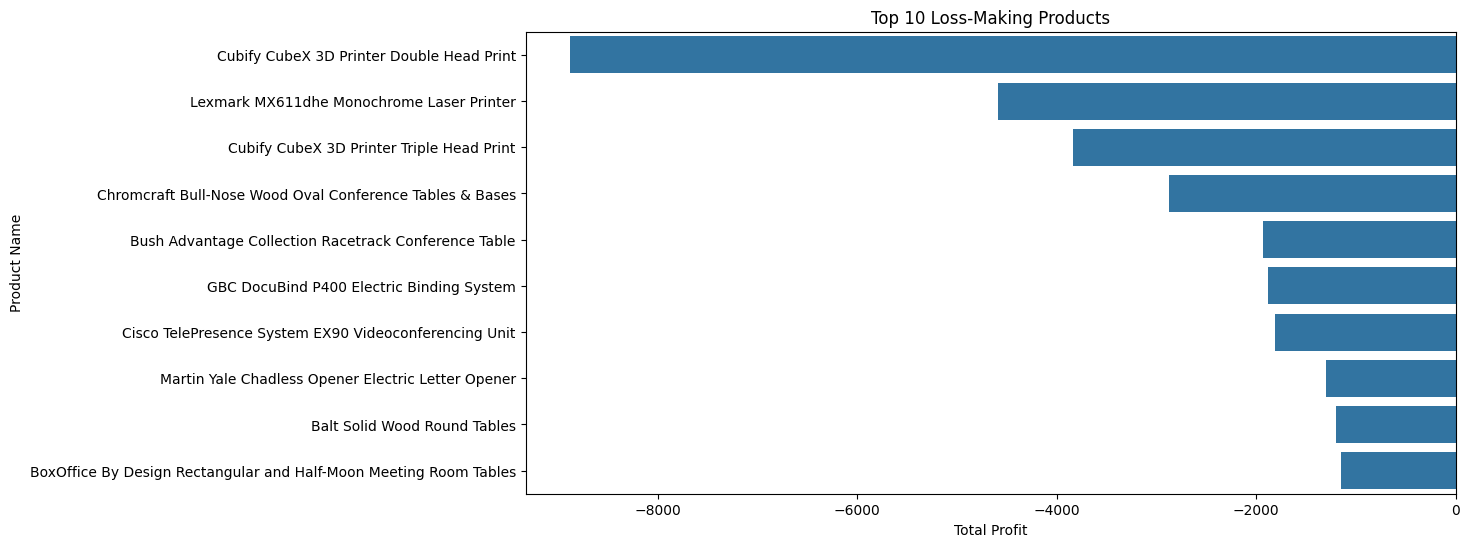

In [ ]:
loss_products = df.groupby("Product Name")["Profit"].sum().sort_values().head(10).reset_index()
# For each product:
# sums total Profit
# sorts from lowest (most negative)
# picks top 10 loss-making products

plt.figure(figsize=(12,6))
sns.barplot(data=loss_products, x="Profit", y="Product Name")
# Shows products causing maximum losses
plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")
plt.show()

**Step 7: Time Analysis**

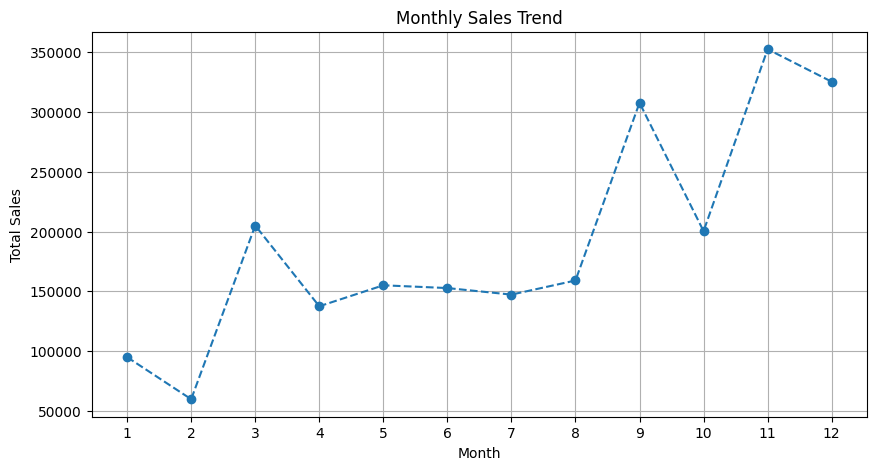

In [ ]:
monthly_sales = df.groupby("Order Month")["Sales"].sum()
# Adds up total sales for each month (1–12)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o",linestyle="--")
# Draws a trend line across months
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

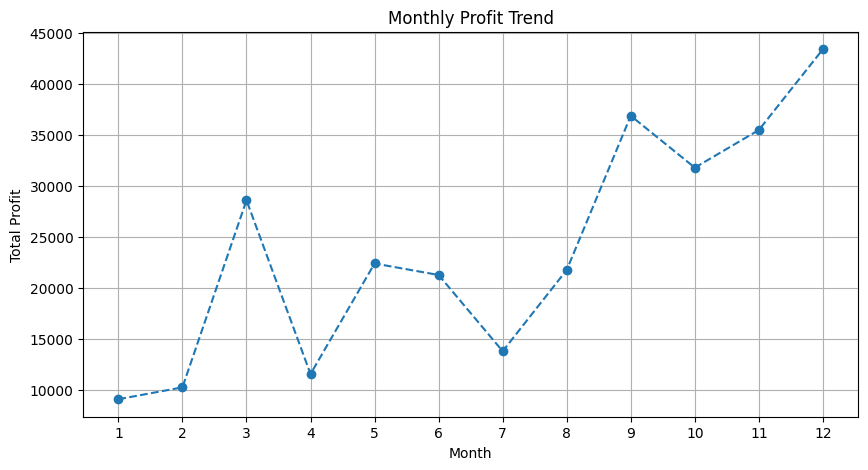

In [ ]:
monthly_profit = df.groupby("Order Month")["Profit"].sum()
# Calculates total profit for each month

plt.figure(figsize=(10,5))
plt.plot(monthly_profit.index, monthly_profit.values, marker="o",linestyle="--")
# Shows profit trend across months
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

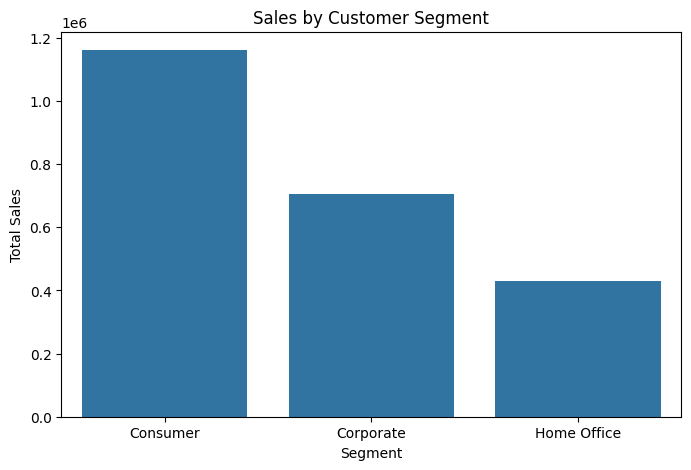

In [ ]:
sales_segment = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False).reset_index()
# For each customer segment:
# sums total Sales
# sorts highest → lowest

plt.figure(figsize=(8,5))
sns.barplot(data=sales_segment, x="Segment", y="Sales")
# Shows which segment contributes most to sales
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.show()

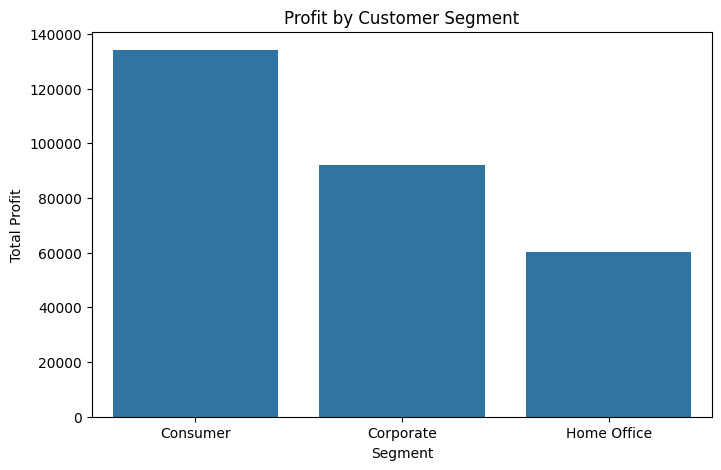

In [ ]:
profit_segment = df.groupby("Segment")["Profit"].sum().sort_values(ascending=False).reset_index()
# For each customer segment:
# sums total Profit
# sorts highest → lowest

plt.figure(figsize=(8,5))
sns.barplot(data=profit_segment, x="Segment", y="Profit")
# Shows which segment is most profitable
plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")
plt.show()

**Step 9: Correlation Analysis**

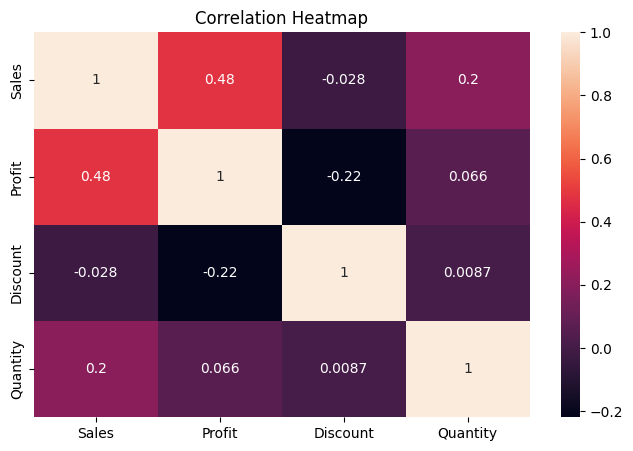

In [ ]:
corr_data = df[["Sales", "Profit", "Discount", "Quantity"]].corr()
# Calculates relationship between variables

plt.figure(figsize=(8,5))
sns.heatmap(corr_data, annot=True)
plt.title("Correlation Heatmap")
plt.show()

**SECTION 3: INSIGHT QUESTIONS (Medium–Hard)**

1. What is total sales and total profit?

In [ ]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("total_sales :",total_sales)
print(" total_profit :",total_profit)

total_sales : 2296919.4883000003
 total_profit : 286409.0805


2. How many orders are present?

In [ ]:
df['Order ID'].nunique()

5009

# Sales Analysis

3. Which category generates the highest sales?

In [ ]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

,Sales
Category,
Technology,836154.0330
Furniture,741718.4233
Office Supplies,719047.0320


4. Which category generates the highest profit?

In [ ]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18463.3316


# Regional Insights
5. Which region performs best?


In [ ]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

,Profit
Region,
West,108418.4489
East,91534.8388
South,46749.4303
Central,39706.3625


6. Which region is loss-making?

In [ ]:
df.groupby('Region')['Profit'].sum().sort_values()

,Profit
Region,
Central,39706.3625
South,46749.4303
East,91534.8388
West,108418.4489


# Profitability
7. Which products are causing losses?

In [ ]:
df[df['Profit'] < 0].sort_values(by='Profit')

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Quantity,Discount,Profit,Order Month,Order Year,Order Day,Delivery Days,Profit Margin,Discount Category,Sales Category
7772,CA-2016-108196,2016-11-25,2016-12-02,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,Ohio,...,5,0.7,-6599.9780,11,2016,25,7,-1.466667,High,Premium
683,US-2017-168116,2017-11-04,2017-11-04,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,North Carolina,...,4,0.5,-3839.9904,11,2017,4,0,-0.480000,Medium,Premium
9774,CA-2014-169019,2014-07-26,2014-07-30,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,Texas,...,8,0.8,-3701.8928,7,2014,26,4,-1.700000,High,Premium
3011,CA-2017-134845,2017-04-17,2017-04-23,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,Colorado,...,5,0.7,-3399.9800,4,2017,17,6,-1.333333,High,Premium
4991,US-2017-122714,2017-12-07,2017-12-13,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,Illinois,...,5,0.8,-2929.4845,12,2017,7,6,-1.550000,High,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4660,CA-2015-112130,2015-05-03,2015-05-07,Standard Class,SV-20785,Stewart Visinsky,Consumer,United States,Philadelphia,Pennsylvania,...,3,0.2,-0.3444,5,2015,3,4,-0.012500,Low,Low
7413,CA-2017-121125,2017-05-30,2017-06-03,Standard Class,MG-17890,Michael Granlund,Home Office,United States,Tigard,Oregon,...,1,0.2,-0.3398,5,2017,30,4,-0.025000,Low,Low
1566,CA-2015-129112,2015-11-29,2015-11-30,First Class,AW-10840,Anthony Witt,Consumer,United States,Allen,Texas,...,3,0.2,-0.2685,11,2015,29,1,-0.012500,Low,Low
1496,CA-2017-152485,2017-09-04,2017-09-08,Standard Class,JD-15790,John Dryer,Consumer,United States,Coppell,Texas,...,1,0.2,-0.2098,9,2017,4,4,-0.012500,Low,Low


8. Does higher discount reduce profit?

In [ ]:
df[['Discount', 'Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219481
Profit,-0.219481,1.000000


# Customer Insights
9. Which segment buys the most?

In [ ]:
df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.293718e+05


10. Which segment is most profitable?

In [ ]:
df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

,Profit
Segment,
Consumer,134119.2092
Corporate,91979.1340
Home Office,60310.7373



# Time-Based Insights
11. Which month has the highest sales?




In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month

df.groupby('Month')['Sales'].sum().sort_values(ascending=False)

,Sales
Month,
11,352461.0710
12,325293.5035
9,307649.9457
3,205005.4888
10,200322.9847
8,159044.0630
5,155028.8117
6,152718.6793
7,147238.0970


12. Identify seasonal trends

<Axes: xlabel='Month'>

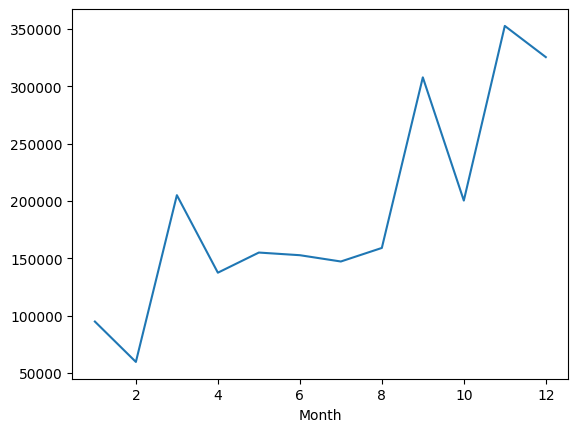

In [ ]:
df.groupby('Month')['Sales'].sum().plot(kind='line')

# Discount Insights
13. At what discount level does loss occur?

In [ ]:
df.groupby('Discount')['Profit'].mean().sort_values()

,Profit
Discount,
0.50,-310.703456
0.45,-226.646464
0.40,-111.927429
0.80,-101.796797
0.70,-95.874060
0.32,-88.560656
0.30,-45.828401
0.60,-43.077212
0.20,24.702572


14. Are high discounts justified?

In [ ]:
df.groupby('Discount')['Profit'].mean()

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.828401
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


# Advanced Insights
15. Identify loss-making categories



In [ ]:
df.groupby('Category')['Profit'].sum()

,Profit
Category,
Furniture,18463.3316
Office Supplies,122490.8008
Technology,145454.9481


16. Identify high sales but low profit products

In [ ]:
df[(df['Sales'] > df['Sales'].mean()) & (df['Profit'] < 0)]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Discount,Profit,Order Month,Order Year,Order Day,Delivery Days,Profit Margin,Discount Category,Sales Category,Month
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,0.45,-383.0310,10,2015,11,7,-0.400000,Medium,High,10
27,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,Pennsylvania,...,0.50,-1665.0522,9,2015,17,4,-0.540000,Medium,Premium,9
38,CA-2015-117415,2015-12-27,2015-12-31,Standard Class,SN-20710,Steve Nguyen,Home Office,United States,Houston,Texas,...,0.32,-46.9764,12,2015,27,4,-0.088235,Medium,High,12
72,US-2015-134026,2015-04-26,2015-05-02,Standard Class,JE-15745,Joel Eaton,Consumer,United States,Memphis,Tennessee,...,0.20,-114.3912,4,2015,26,6,-0.137500,Low,High,4
84,US-2017-119662,2017-11-13,2017-11-16,First Class,CS-12400,Christopher Schild,Home Office,United States,Chicago,Illinois,...,0.20,-48.9549,11,2017,13,3,-0.212500,Low,Medium,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9899,US-2014-117380,2014-03-28,2014-04-03,Standard Class,MP-18175,Mike Pelletier,Home Office,United States,Springfield,Ohio,...,0.40,-143.2548,3,2014,28,6,-0.433333,Medium,Medium,3
9912,CA-2015-132388,2015-10-10,2015-10-12,First Class,KN-16390,Katherine Nockton,Corporate,United States,Santa Barbara,California,...,0.20,-54.3204,10,2015,10,2,-0.150000,Low,Medium,10
9919,CA-2016-149272,2016-03-15,2016-03-19,Standard Class,MY-18295,Muhammed Yedwab,Corporate,United States,Bryan,Texas,...,0.30,-143.4310,3,2016,15,4,-0.271429,Medium,High,3
9931,CA-2015-104948,2015-11-13,2015-11-17,Standard Class,KH-16510,Keith Herrera,Consumer,United States,San Bernardino,California,...,0.15,-40.1960,11,2015,13,4,-0.058824,Low,High,11



# Visualization Tasks
Sales by category

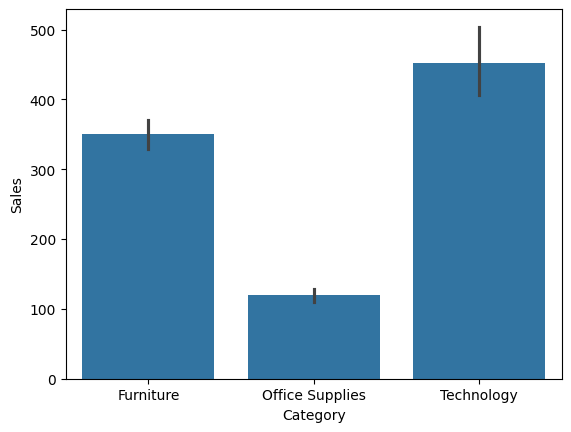

In [ ]:
sns.barplot(x='Category', y='Sales', data=df)
plt.show()

Profit by region


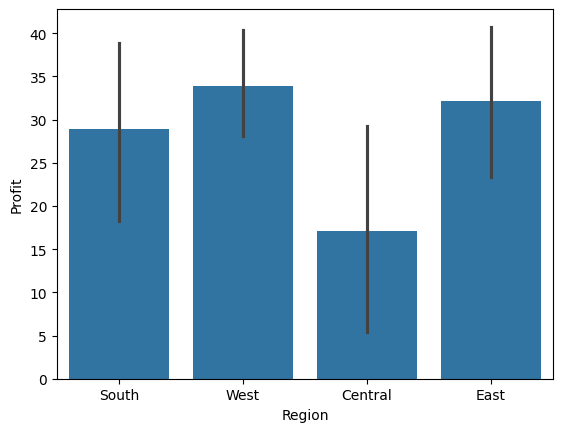

In [ ]:
sns.barplot(x='Region', y='Profit', data=df)
plt.show()

Discount vs profit plot


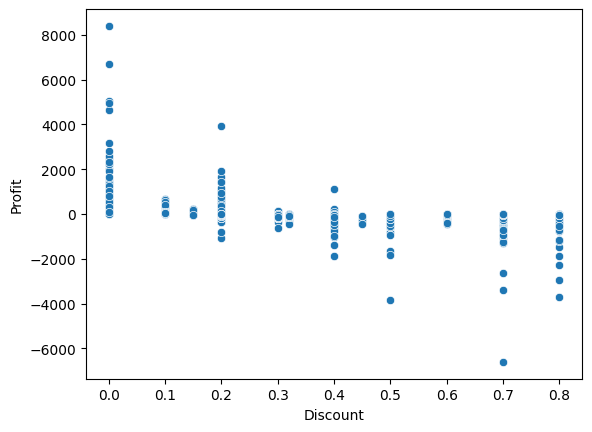

In [ ]:
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.show()

Correlation heatmap

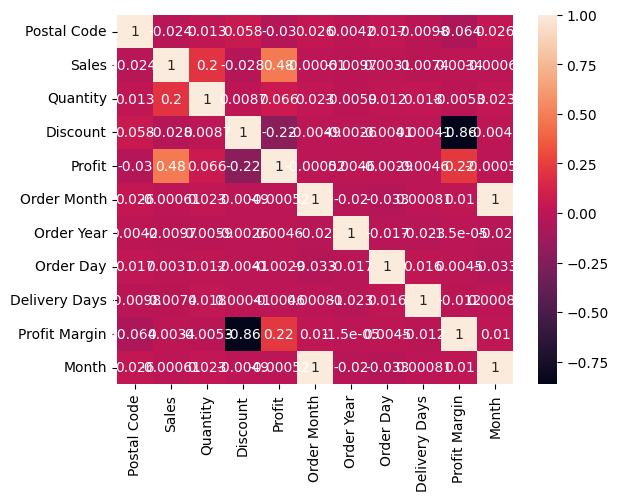

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()